In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
np.set_printoptions(legacy='1.25')

In [2]:
plt.rcParams["figure.figsize"] = [16, 9]
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 24
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["font.family"] = "serif"

In [3]:
stocks = ['KO', 'PEP', 'NVDA','KSU']
seq_len = 150

id = 'vb7m8jvt'
path_storage = f'storage/{id}'

seed, epoch = 42, 5
file_name = f'synthetics_epoch={epoch}_seed={seed}'

In [4]:
real = pd.read_csv('data/stocks/midprice_volume__KO_PEP_NVDA_KSU__train.csv')[[f'mid_price_{s}' for s in stocks]].values
real = np.asarray([real[i*seq_len:(i+1)*seq_len] for i in range(len(real) // seq_len)]).transpose(0, 2, 1)
corrcoefs_real = np.asarray([np.corrcoef(s) for s in real])
n_sampels = len(real)
real.shape, corrcoefs_real.shape

((453, 4, 150), (453, 4, 4))

In [5]:
with open(f'{path_storage}/inference_data/guidance_scale=0/{file_name}.npy', 'rb') as f:
    synthetic = np.load(f)
indices = np.random.choice(len(synthetic), n_sampels, replace=False)
synthetic = synthetic[indices].transpose(0, 2, 1)
corrcoefs_synthetic_noGuidance = np.asarray([np.corrcoef(s) for s in synthetic])

In [6]:
with open(f'{path_storage}/inference_data/guidance_scale=250/critic_epoch=121/{file_name}.npy', 'rb') as f:
    synthetic = np.load(f)
indices = np.random.choice(len(synthetic), n_sampels, replace=False)
synthetic = synthetic[indices].transpose(0, 2, 1)
corrcoefs_synthetic_guidance = np.asarray([np.corrcoef(s) for s in synthetic])

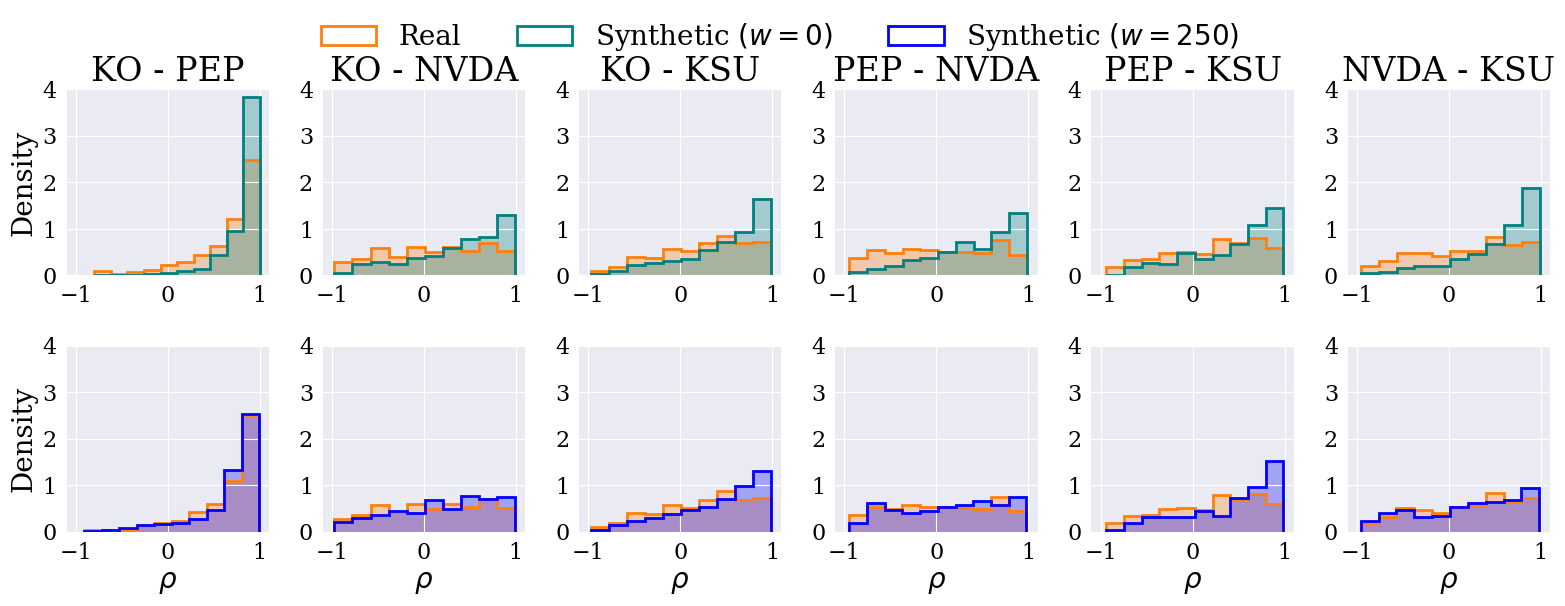

In [10]:
I, J = np.triu_indices(len(stocks), k=1)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))

wass_noGuidance = dict()
wass_guidance = dict()
add_label = True
for i, j, ax1, ax2 in zip(I, J, *axes):
    title = f'{stocks[i]} - {stocks[j]}'
    ax1.set_title(title)
    hist = ax1.hist(
        [corrcoefs_synthetic_noGuidance[:, i, j], corrcoefs_real[:, i, j]], 
        color=['#008080', 'C1'],
        density=True, histtype="step", linewidth=2, 
        label=[r'Synthetic $(w=0)$', 'Real'] if add_label else None
    )
    hist = ax1.hist(
        [corrcoefs_synthetic_noGuidance[:, i, j], corrcoefs_real[:, i, j]], 
        color=['#008080', 'C1'],
        density=True, histtype="stepfilled", alpha=.3
    )
    wass_noGuidance[title] = wasserstein_distance(*hist[0]).round(2)

    hist = ax2.hist(
        [corrcoefs_synthetic_guidance[:, i, j], corrcoefs_real[:, i, j]], 
        color=['Blue', 'C1'],
        density=True, histtype="step", linewidth=2, 
        label=[r'Synthetic $(w=250)$', 'Real'] if add_label else None
    )
    hist = ax2.hist(
        [corrcoefs_synthetic_guidance[:, i, j], corrcoefs_real[:, i, j]], 
        color=['Blue', 'C1'],
        density=True, histtype="stepfilled", alpha=.3
    )
    wass_guidance[title] = wasserstein_distance(*hist[0]).round(2)

    add_label = False
    
    ax2.set_xlabel(r'$\rho$')

axes[0, 0].set_ylabel('Density')
axes[1, 0].set_ylabel('Density')

for ax in axes.ravel():
    ax.set_xlim((-1.1, 1.1))
    ax.set_ylim((0, 4))
    ax.set_facecolor('#eaeaf2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(bottom=False, left=False, which='both')
    ax.grid(True, linestyle='solid', c='w')

h1, l1 = axes[0, 0].get_legend_handles_labels()
h2, l2 = axes[1, 0].get_legend_handles_labels()
handles = h1 + h2[1:]
labels = l1 + l2[1:]
# fig.suptitle(f'Epoch: {epoch}')
fig.legend(loc='upper center', ncols=3, bbox_to_anchor=[.5, 1.05], frameon=False, handles=handles, labels=labels)
fig.tight_layout()
plt.savefig('correlations.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

In [14]:
print('Guidance')
print(str(wass_guidance)[1:-1].replace(', ', '\n').replace("'", ''))

Guidance
KO - PEP: 5.4
KO - NVDA: 7.4
KO - KSU: 13.8
PEP - NVDA: 5.6
PEP - KSU: 17.2
NVDA - KSU: 4.2


In [15]:
print('No Guidance')
print(str(wass_noGuidance)[1:-1].replace(', ', '\n').replace("'", ''))

No Guidance
KO - PEP: 21.6
KO - NVDA: 18.6
KO - KSU: 17.4
PEP - NVDA: 20.6
PEP - KSU: 17.2
NVDA - KSU: 25.2
